In [18]:
import numpy as np
import matplotlib.pyplot as plt
from rastermap import Rastermap
from pathlib import Path

s2p_dir = Path("/Users/suthardr/Desktop/621N_FC/suite2p/plane0/")

# spks is neurons by time
spks = np.load(s2p_dir / "F.npy").astype("float32")
iscell = np.load(s2p_dir / "iscell.npy", allow_pickle=True)


In [19]:
# Create a boolean mask for true cells
cell_mask = iscell[:, 0].astype(bool)

# Filter data
F_spks = spks[cell_mask, :]

print(f"Original ROIs: {spks.shape[0]}, Filtered cells: {F_spks.shape[0]}")

Original ROIs: 103, Filtered cells: 40


In [20]:
from scipy.stats import zscore

F_spksZ = zscore(F_spks, axis=1)

2026-05-27 12:20:30,445 [INFO] normalizing data across axis=1
2026-05-27 12:20:30,457 [INFO] projecting out mean along axis=0
2026-05-27 12:20:30,465 [INFO] data normalized, 0.02sec
2026-05-27 12:20:30,466 [INFO] sorting activity: 34 valid samples by 13115 timepoints


/Users/suthardr/Documents/GitHub/CalciumKit/venv/lib/python3.9/site-packages/rastermap/rastermap.py:278: RuntimeWarning: invalid value encountered in divide
  X /= stdx[:,np.newaxis]


2026-05-27 12:20:30,958 [INFO] n_PCs = 34 computed, 0.51sec


/Users/suthardr/Documents/GitHub/CalciumKit/venv/lib/python3.9/site-packages/rastermap/rastermap.py:357: UserWarning: data has <= 50 samples, 

                                going to skip clustering and sort samples
  warnings.warn("""data has <= 50 samples, \n


2026-05-27 12:20:31,240 [INFO] clusters sorted, time 0.80sec
2026-05-27 12:20:31,255 [INFO] clusters upsampled, time 0.81sec
2026-05-27 12:20:31,262 [INFO] rastermap complete, time 0.82sec


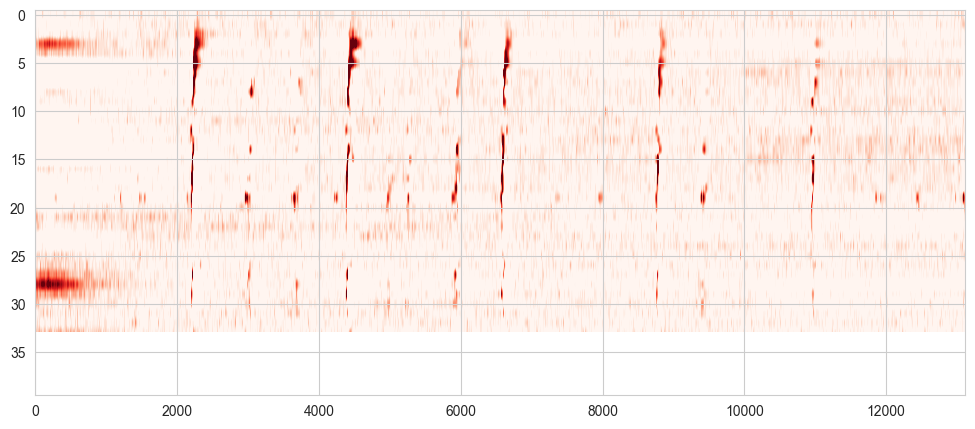

In [22]:
# fit rastermap
model = Rastermap(n_PCs=50, n_clusters=50,
                  locality=0.5, time_lag_window=10).fit(F_spks)
y = model.embedding # neurons x 1
isort = model.isort

# visualize binning over neurons
X_embedding = model.X_embedding

# plot
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(111)
ax.imshow(X_embedding, vmin=0, vmax=3, cmap="Reds", aspect="auto")